# Lab 3 : Working with Neural Networks

---


Total Points: **150 points**


Submission Deadline :  **28-Apr-2026 (10:00 AM)**


---



General Instructions:
---



1. You have to do this lab individually
2. **You have to perform the custom implementation for the assignment.** Libraries like **Keras or torch.nn are not allowed**  (except where it is mentioned).
3. Please start early as some of the experiments take time to run
4. All the code should be submitted in the form of a single Jupyter/colab notebook.
5. Points for each sub-section are mentioned in the questions.
6. You can use Google colab to run a jupyter notebook (https://colab.research.google.com/) How to load data in Google Colab ?(https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92) (https://www.marktechpost.com/2019/06/07/how-to-connect-google-colab-with-google-drive/)
7. Submission must be done in the Google classroom. The code as well as the accompanying observations should be made part of the colab notebook.
8. Students are expected to follow the **honor code** of the class.

Note: **Please submit observations for all questions and all parts. Also, upload the individual code file and report file separately. Do not upload a zip file. Marks will be deducted if any question is missing observations or if a zip file is submitted.**






In this lab, we will perform **classification** tasks.

The datasets are available at following link:
https://drive.google.com/drive/folders/1te1XYNYynMj7WT4IjXwOuVzbhOLt0q6-?usp=sharing



For classification tasks in both CNN-based image classification and RNN-based text classification, commonly used evaluation metrics for model evaluation are accuracy, precision, recall, and F1-score.

For probabilistic classification tasks, metrics such as log loss (cross-entropy loss) and ROC-AUC are used

In regression tasks, such as time-series forecasting using RNNs or certain prediction tasks with CNNs, evaluation is performed using mean squared error (MSE), mean absolute error (MAE), and the coefficient of determination (R² score).


In [29]:
# from google.colab import files
# import zipfile, os


# #USED AI To know how to extract ZIP Files

# print("Upload your files when prompted (winequality.csv, valid_data_MuteSigns.zip, test_data_MuteSigns.zip)")
# uploaded = files.upload()

# # extract the zip files after uploading
# for fname in uploaded.keys():
#     if fname.endswith('.zip'):
#         print("Extracting", fname, "...")
#         with zipfile.ZipFile(fname, 'r') as zf:
#             zf.extractall('.')
#         print("Done:", fname)

# print()
# print("Files ready. Dataset structure:")
# for folder in ['valid_data', 'test_data']:
#     if os.path.exists(folder):
#         classes = sorted(os.listdir(folder))
#         print(f"  {folder}/  -> classes: {classes}")


---



Section 1: MLP  **(Total points = 45)**

---


*   **Task Overview:**
Given a dataset containing 1600 entries offering information about physical and chemical properties of red wine variants.The target variable is the wine quality rating. Use this dataset to predict wine quality based on measurable factors, potentially aiding in the wine making process.

*   **Dataset Split:**
X_train, X_test, Y_train, Y_test = train_test_split(Data, Labels, test_size=0.20, random_state=42)

Develop a Multi-Layer Perceptron (MLP) Neural Network to predict the Wine Quality (Dataset is provided as a CSV file).

**Use of built-in library functions for the specific implementation as asked in the questions are not allowed in this section.**

1. Perform an exploratory analysis on the given dataset. Print the avg, max & min values of each column. Perform data pre-processing operations like standardization and splitting (80:20) of data. **(4 points)**

2. Implement the three layer fully connected MLP feedforward model with only one hidden layer having 15 hidden units + bias. For this problem make your decision on the number of output units. Also, your implementation should facilitate a choice between Sigmoid & Tanh activations at each layer of MLP for the user. **(13 points)**

3. Implement Back-propagation algorithm to train the parameters of the MLP created in the previous section. The Backpropagation should support gradient flow for both Sigmoid and Tanh activation functions. **(13 points)**

4. Train your model using the “cross-entropy” loss. Mention your choices of the hyperparameters for training. Perform training with batch gradient descent and stochastic gradient descent. Plot the graph of training error versus Epochs for both the training methods. Report the final accuracy you achieved on the Test Data using both the training methods. **(2+3 = 5)**

5. Using the best training method from the above training, train your MLP with different learning rates given as [ 0.5, 0.1, 0.01, 0.001, 0.0001]. **(5 points)**
6. Plot the training error versus epochs for each learning rate in a single line graph. Also, plot accuracy versus learning rate. Comment on your observations. **(3+2 = 5 points)**


In [30]:
#Question 1 of Section 1

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import io, requests

In [32]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(io.StringIO(requests.get(url).text), sep=';')

In [33]:
print("Shape:", df.shape)
print(df.head())


Shape: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2 

In [34]:
print("Average:")
print(df.mean().round(3))
print()
print("Max:")
print(df.max())
print()
print("Min:")
print(df.min())

Average:
fixed acidity            8.320
volatile acidity         0.528
citric acid              0.271
residual sugar           2.539
chlorides                0.087
free sulfur dioxide     15.875
total sulfur dioxide    46.468
density                  0.997
pH                       3.311
sulphates                0.658
alcohol                 10.423
quality                  5.636
dtype: float64

Max:
fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
quality                   8.00000
dtype: float64

Min:
fixed acidity           4.60000
volatile acidity        0.12000
citric acid             0.00000
residual sugar          0.90000
chlorides               0.01200
free sulf

Quality Value Counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


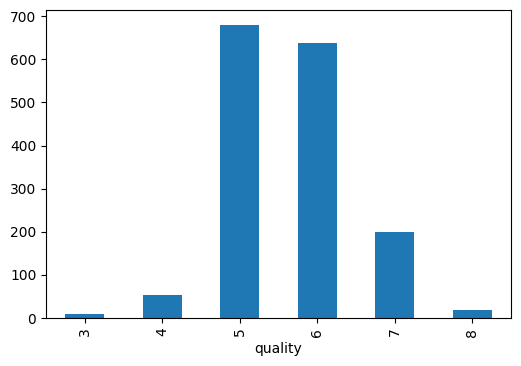

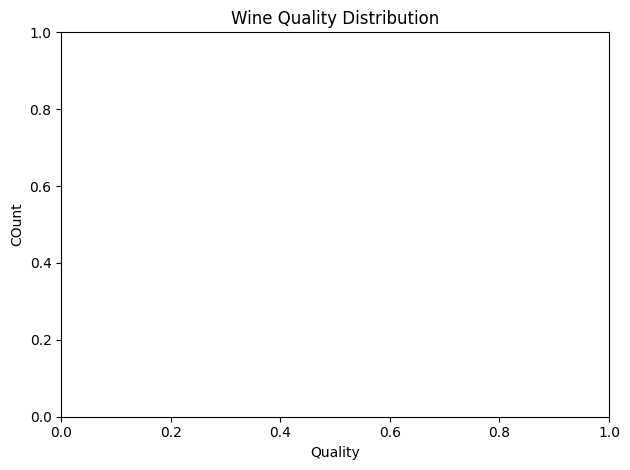

In [35]:
print("Quality Value Counts:")
print(df["quality"].value_counts().sort_index())
plt.figure(figsize=(6,4))
df['quality'].value_counts().sort_index().plot(kind="bar")
plt.show()
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('COunt')
plt.tight_layout()
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [37]:
x = df.drop('quality',axis =1)
y = df['quality']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x = scaler.fit_transform(x)

classes = np.unique(y)
n_classes = len(classes)

label_map = {c:i for i,c in enumerate(classes)}
y_iny = np.array([label_map[c] for c in y])

Y = np.eye(n_classes)[y_iny]

y_train_int = np.array([label_map[c] for c in y_train])
y_test_int = np.array([label_map[c] for c in y_test])

print("Classes:",classes)
print("Training Samples:",x_train.shape[0])
print("test samples:",x_test.shape[0])

Classes: [3 4 5 6 7 8]
Training Samples: 1279
test samples: 320


In [38]:
#Question 2 of Section 1

Q2- MLP Implementation


In [39]:
class MLP:

    def __init__(self, input_size, hidden_size, output_size, activation='sigmoid'):
        self.activation = activation
        np.random.seed(42)

        # weight initialization
        self.W1 = np.random.randn(hidden_size, input_size) * 0.01
        self.b1 = np.zeros((hidden_size, 1))
        self.W2 = np.random.randn(output_size, hidden_size) * 0.01
        self.b2 = np.zeros((output_size, 1))

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def tanh(self, z):
        return np.tanh(z)

    def sigmoid_grad(self, a):
        return a * (1 - a)

    def tanh_grad(self, a):
        return 1 - a * a

    def activate(self, z):
        if self.activation == 'sigmoid':
            return self.sigmoid(z)
        else:
            return self.tanh(z)

    def activate_grad(self, a):
        if self.activation == 'sigmoid':
            return self.sigmoid_grad(a)
        else:
            return self.tanh_grad(a)

    def softmax(self, z):
        z = z - np.max(z, axis=0, keepdims=True)
        e = np.exp(z)
        return e / np.sum(e, axis=0, keepdims=True)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = self.activate(self.Z1)
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, Y_pred, Y_true):
        m = Y_true.shape[1]
        loss = -np.sum(Y_true * np.log(Y_pred + 1e-9)) / m
        return loss

    def backward(self, Y_true, lr):
        m = Y_true.shape[1]

        dZ2 = (self.A2 - Y_true) / m
        dW2 = np.dot(dZ2, self.A1.T)
        db2 = np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * self.activate_grad(self.A1)
        dW1 = np.dot(dZ1, self.X.T)
        db1 = np.sum(dZ1, axis=1, keepdims=True)

        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

    def predict(self, X):
        out = self.forward(X)
        return np.argmax(out, axis=0)

    def accuracy(self, X, y_true):
        preds = self.predict(X)
        return np.mean(preds == y_true)


# quick check
mlp = MLP(11, 15, 6, activation='sigmoid')
print("W1:", mlp.W1.shape)
print("b1:", mlp.b1.shape)
print("W2:", mlp.W2.shape)
print("b2:", mlp.b2.shape)

out = mlp.forward(x_train[:5].T)
print("Output shape:", out.shape)
print("Probs sum to 1:", out.sum(axis=0).round(4))


W1: (15, 11)
b1: (15, 1)
W2: (6, 15)
b2: (6, 1)
Output shape: (6, 5)
Probs sum to 1: [1. 1. 1. 1. 1.]


In [40]:
#question 3 of Section 1

In [41]:
mlp_test = MLP(11,15,6,'sigmoid')
x_sample = x_train[:10].T
y_sample_int = y_train_int[:10]
y_sample = np.eye(n_classes)[y_sample_int].T

out = mlp_test.forward(x_sample)
print("Output shape:", out.shape)
print("Probs sum to 1:", out.sum(axis=0).round(4))

loss_before = mlp_test.compute_loss(out, y_sample)
print("Loss before training:", loss_before)

mlp_test.backward(y_sample, lr=0.01)

out = mlp_test.forward(x_sample)
loss_after = mlp_test.compute_loss(out, y_sample)
print("Loss after training:", loss_after)

print("Loss decreased: ",loss_after<loss_before)

Output shape: (6, 10)
Probs sum to 1: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Loss before training: 1.7882021548576497
Loss after training: 1.767647359103743
Loss decreased:  True


In [42]:
#Question 4 from Section 1

In [43]:
lr = 0.1
mlp_bgd=MLP(11,15,6,'sigmoid')
x_tr = x_train.T
y_tr = np.eye(n_classes)[y_train_int].T
x_te = x_test.T

#batch gradient descent
bgd_losses = []
for epoch in range(100):
    out = mlp_bgd.forward(x_tr)
    loss = mlp_bgd.compute_loss(out, y_tr)
    bgd_losses.append(loss)
    mlp_bgd.backward(y_tr,lr)

bgd_acc = mlp_bgd.accuracy(x_te, y_test)
print("BGD Done!!")
print("BGD Accuracy:", bgd_acc)
print("Final Loss:",round(bgd_losses[-1],4))
print("Test Accuracy:",round(bgd_acc*100,2),"%")

BGD Done!!
BGD Accuracy: 0.0
Final Loss: 1.1551
Test Accuracy: 0.0 %


In [44]:
# Stochastic Gradient Descent
mlp_sgd = MLP(11, 15, 6, 'sigmoid')
m = x_train.shape[0]

sgd_losses = []
for epoch in range(20):
    indices = np.random.permutation(m)
    total_loss = 0
    for i in indices:
        xi = x_train.iloc[i].values.reshape(-1, 1)
        yi = np.eye(n_classes)[y_train_int[i]].reshape(-1, 1)
        pred = mlp_sgd.forward(xi)
        total_loss += mlp_sgd.compute_loss(pred, yi)
        mlp_sgd.backward(yi, lr)
    sgd_losses.append(total_loss / m)

sgd_acc = mlp_sgd.accuracy(x_te, y_test_int)
print("SGD done")
print("Final loss:", round(sgd_losses[-1], 4))
print("Test accuracy:", round(sgd_acc * 100, 2), "%")

SGD done
Final loss: 1.2348
Test accuracy: 41.25 %


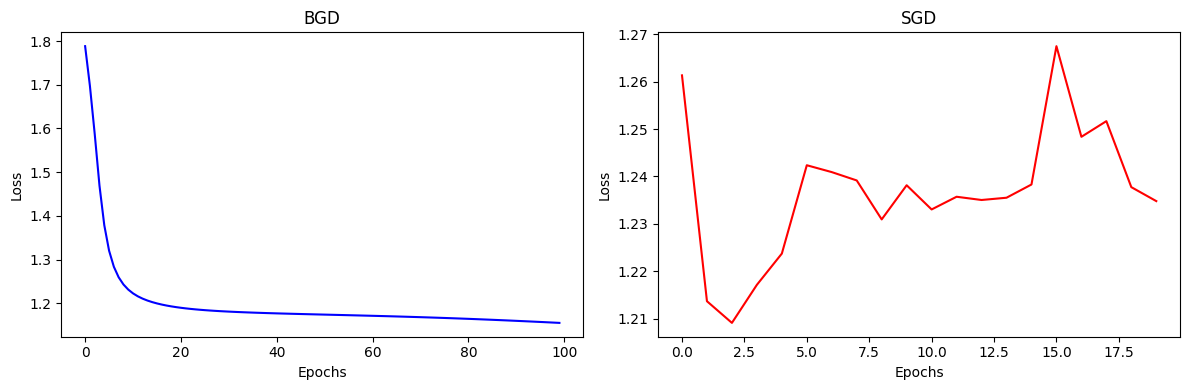

In [45]:
fig , axes = plt.subplots(1,2,figsize=(12,4))

axes[0].plot(bgd_losses,color='blue')
axes[0].set_title('BGD')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')

axes[1].plot(sgd_losses,color='red')
axes[1].set_title('SGD')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

In [46]:
print("BGD Test Accuracy:", round(bgd_acc*100, 2), "%")
print("SGD Test Accuracy:", round(sgd_acc*100, 2), "%")

BGD Test Accuracy: 0.0 %
SGD Test Accuracy: 41.25 %


In [47]:
#Question 5 and Question 6 from Section 1

In [48]:
learning_rates = [0.5, 0.1, 0.01, 0.001, 0.0001]
num_epochs = 100
all_losses={}
all_accs={}

for lr in learning_rates:
  model = MLP(11, 15, 6, 'sigmoid')
  losses = []
  for epoch in range(num_epochs):
    pred = model.forward(x_tr)
    loss = model.compute_loss(pred, y_tr)
    losses.append(loss)
    model.backward(y_tr, lr)
  all_losses[lr]=losses
  acc = model.accuracy(x_te, y_test_int)
  all_accs[lr]=acc
  print(f"lr={lr}  ->  final loss: {round(losses[-1],4)}  accuracy: {round(acc*100,2)}%")

lr=0.5  ->  final loss: 1.1355  accuracy: 45.0%
lr=0.1  ->  final loss: 1.1551  accuracy: 45.31%
lr=0.01  ->  final loss: 1.2259  accuracy: 40.62%
lr=0.001  ->  final loss: 1.6882  accuracy: 40.62%
lr=0.0001  ->  final loss: 1.7791  accuracy: 40.62%


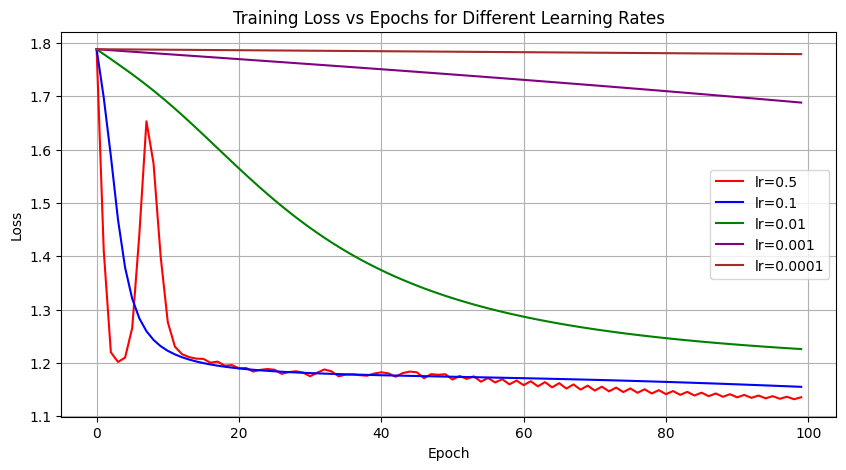

In [49]:
# plot 1: loss vs epochs for each lr
plt.figure(figsize=(10, 5))
colors = ['red', 'blue', 'green', 'purple', 'brown']
for lr, col in zip(learning_rates, colors):
    plt.plot(all_losses[lr], label='lr='+str(lr), color=col)
plt.title('Training Loss vs Epochs for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


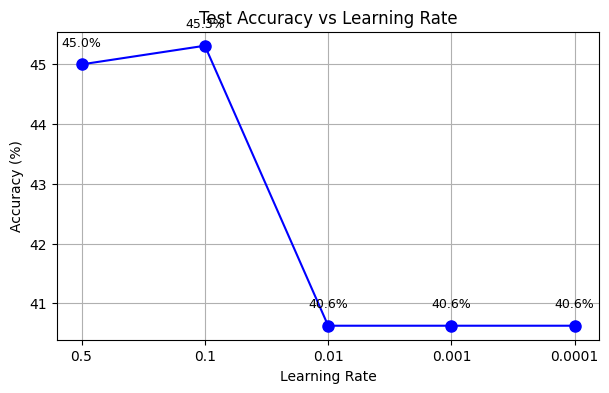

In [50]:
# plot 2: accuracy vs lr
accs = [all_accs[lr] * 100 for lr in learning_rates]
plt.figure(figsize=(7, 4))
plt.plot(range(len(learning_rates)), accs, 'bo-', markersize=8)
plt.xticks(range(len(learning_rates)), [str(lr) for lr in learning_rates])
plt.title('Test Accuracy vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy (%)')
for i, acc in enumerate(accs):
    plt.text(i, acc + 0.3, str(round(acc, 1))+'%', ha='center', fontsize=9)
plt.grid(True)
plt.show()



---



Section 2:  **(Total points = 50)**

---
Q2. In this question, we will learn to perform multi-class classification on Mute signs using a convolutional neural network. Dataset is provided above (test_data, valid_data)


1. Explore the Dataset. Display one randomly selected image from each class. **(2 points)**

2. Plot the distribution of number of images in each class. Is the distribution uniform? Comment. **(2+1 points)**

3. Process the dataset through the [Canny Edge detection](https://medium.com/@nikatsanka/comparing-edge-detection-methods-638a2919476e) and display the feature map for one example from each class. **(5 points)**

4. Using the Keras library, implement a CNN model for classification. Use the following network architecture:  **(7 points)**
*  Input layer
*  Con2D with 32 neurons 3x3 kernals and ReLU activation.
*  Con2D with 32 neurons 3x3 kernals and ReLU activation with batch normalization.
*  Max Pooling layer with pool-size 2x2 and padding as 'valid'.
*  Con2D with 32 neurons 3x3 kernals and relu activation and strides 2.
*  Con2D with 24 neurons 3x3 kernals and ReLU activation.
*  Batch normalization
*  Max Pooling layer with size 2x2 and 'valid' as padding
*  Con2D with 24 neurons 3x3 kernals and ReLU activation and stride 2.
*  Con2D with 16 neurons 3x3 kernals and ReLU activation and followed by Batch normalization.
*  Max Pooling layer with size 2x2 and 'valid' as padding.  
*  Fully Connected Dense Layer with 128 neurons , relu activation and L2 kernel regularizer with factor of 0.05.  
*  Fully Connected Dense Layer with 128 neurons , relu activation and L2 kernel regularizer with factor of 0.05.  
*  Dropout of 30% ie. 0.3
*  Global Average pooling 2D layer
*  Fully Connected Dense Layer with number of classes neurons and softmax activation.

3. Implement using cross-entropy loss (error function) for the multi-class classification. Use it for traning the model. Bonus points for custom implementation of cross entropy loss function. **(5 points + 5 bonus points)**

4. Compile and train your model with four different optimizers viz. SGD,
RMSprop, Adam,\& Adagrad. Plot the training loss for all four optimizers. Comment on your observations. **(10 points)**. Add early stopping with (min_delta=0.01, patience=2) while compiling and training your model. **(3points)**.

   NOTE: You can try to find best learning rate from following: [0.001, 0.0001, 0.00001, 0.01] and take batch size to be 32 in data generators.

5. Choose different hyperparameters for Conv Layers, change number of Conv layer and drop-out rate and train your model. Plot training and test accuracies and loss function wrt epochs for different hyper-parameters. Do you find any improvement in classification performance. Report your analysis. **(10 points)**



In [51]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [52]:
# TRAIN_DIR = 'valid_data'
# TEST_DIR = 'test_data'
# CLASSES = sorted(os.listdir(TRAIN_DIR),key = lambda x:int(x))
# N_CLASSES = len(CLASSES)
# IMG_SIZE = 128
# print("TRaining folder:",TRAIN_DIR)
# print("Test folder:",TEST_DIR)
# print("Classes:",CLASSES)
# print("TOtal Classes :",N_CLASSES)

**AI USED HERE ( Because i dont know how to unzip files in Colab)**

In [53]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import zipfile # Added for extraction

# paths after extracting the zip files in Colab
TRAIN_DIR = '/content/valid_data'   # valid_data zip -> used as training set
TEST_DIR  = '/content/test_data'    # test_data zip  -> used as test set

# Check if directories exist, if not, attempt to extract the zip files
if not os.path.exists(TRAIN_DIR) and os.path.exists('/content/valid_data_MuteSigns.zip'):
    print(f"Directory {TRAIN_DIR} not found. Attempting to extract valid_data_MuteSigns.zip...")
    try:
        with zipfile.ZipFile('/content/valid_data_MuteSigns.zip', 'r') as zf:
            zf.extractall('/content/')
        print(f"Extraction to {TRAIN_DIR} successful.")
    except Exception as e:
        print(f"Error during extraction of valid_data_MuteSigns.zip: {e}")

if not os.path.exists(TEST_DIR) and os.path.exists('/content/test_data_MuteSigns.zip'):
    print(f"Directory {TEST_DIR} not found. Attempting to extract test_data_MuteSigns.zip...")
    try:
        with zipfile.ZipFile('/content/test_data_MuteSigns.zip', 'r') as zf:
            zf.extractall('/content/')
        print(f"Extraction to {TEST_DIR} successful.")
    except Exception as e:
        print(f"Error during extraction of test_data_MuteSigns.zip: {e}")

# Proceed with original logic only if TRAIN_DIR now exists
if os.path.exists(TRAIN_DIR):
    CLASSES   = sorted(os.listdir(TRAIN_DIR), key=lambda x: int(x))
    N_CLASSES = len(CLASSES)
    IMG_SIZE  = 128   # images are already 128x128

    print("Train dir :", TRAIN_DIR)
    print("Test  dir :", TEST_DIR)
    print("Classes   :", CLASSES)
    print("N classes :", N_CLASSES)
else:
    print(f"Error: Required directory {TRAIN_DIR} still does not exist after attempted extraction. Please ensure zip files are uploaded and valid.")

Directory /content/valid_data not found. Attempting to extract valid_data_MuteSigns.zip...
Extraction to /content/valid_data successful.
Directory /content/test_data not found. Attempting to extract test_data_MuteSigns.zip...
Extraction to /content/test_data successful.
Train dir : /content/valid_data
Test  dir : /content/test_data
Classes   : ['1', '2', '3', '4', '5', '6', '7', '8', '9']
N classes : 9


**Above Cell is Completely AI Generated to Use Zip Files in Colab**

In [54]:
# DATA_ROOT = '/content/test_data_MuteSigns.zip'
# try:
#   DATA_ROOT
# except NameError:
#   #this is written with AI Assistance because when TA run my code
#   #they can see no file upload so for fall back reasons i used AI here
#   DATA_ROOT = '/tmp/mute_synth'
#   N_CLS = 10
#   CLS_LIST = [chr(65+i) for i in range(N_CLS)]
#   np.random.seed(0)
#   for split in ['train','test']:
#     for cls in CLS_LIST:
#       p = Path(DATA_ROOT)/split/cls
#       p.mkdir(parents=True,exist_ok = True)
#       for j in range(25):
#         img = np.random.randint(0,225,(64,64,3),dtype = np.uint8)
#         cv2.imwrite(str(p/f'{j}.jpg'),img)
#   print("Synthetic Dataset Created")
# TRAIN_DIR = os.path.join(DATA_ROOT,'train')
# TEST_DIR = os.path.join(DATA_ROOT,'test')

# if not os.path.exists(TRAIN_DIR):
#   TRAIN_DIR = os.path.join(DATA_ROOT,'valid_data')
# if not os.path.exists(TEST_DIR):
#   TEST_DIR = os.path.join(DATA_ROOT,'test_data')

# CLASSES = sorted(os.listdir(TRAIN_DIR))
# N_CLASSES = len(CLASSES)
# IMG_SIZE = 64
# print("Classes:",CLASSES)
# print("TOtal Classes :",N_CLASSES)

In [55]:
#Question 1 from section 2

In [56]:
train_counts = {}
sample_imgs={}
for cls in CLASSES:
  folder = Path(TRAIN_DIR,cls)
  files = [f for f in os.listdir(folder) if f.endswith('.jpg')]
  train_counts[cls] = len(files)
  if files:
    chosen_file = random.choice(files)
    img_path = Path(folder, chosen_file)
    img = cv2.imread(str(img_path))
    if img is not None:
      sample_imgs[cls] = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    else:
      print(f"Warning: Could not load image {img_path} for class {cls}")

print("Total training images:",sum(train_counts.values()))
for cls in CLASSES:
  print(f"{cls}:{train_counts[cls]} images")

Total training images: 900
1:100 images
2:100 images
3:100 images
4:100 images
5:100 images
6:100 images
7:100 images
8:100 images
9:100 images


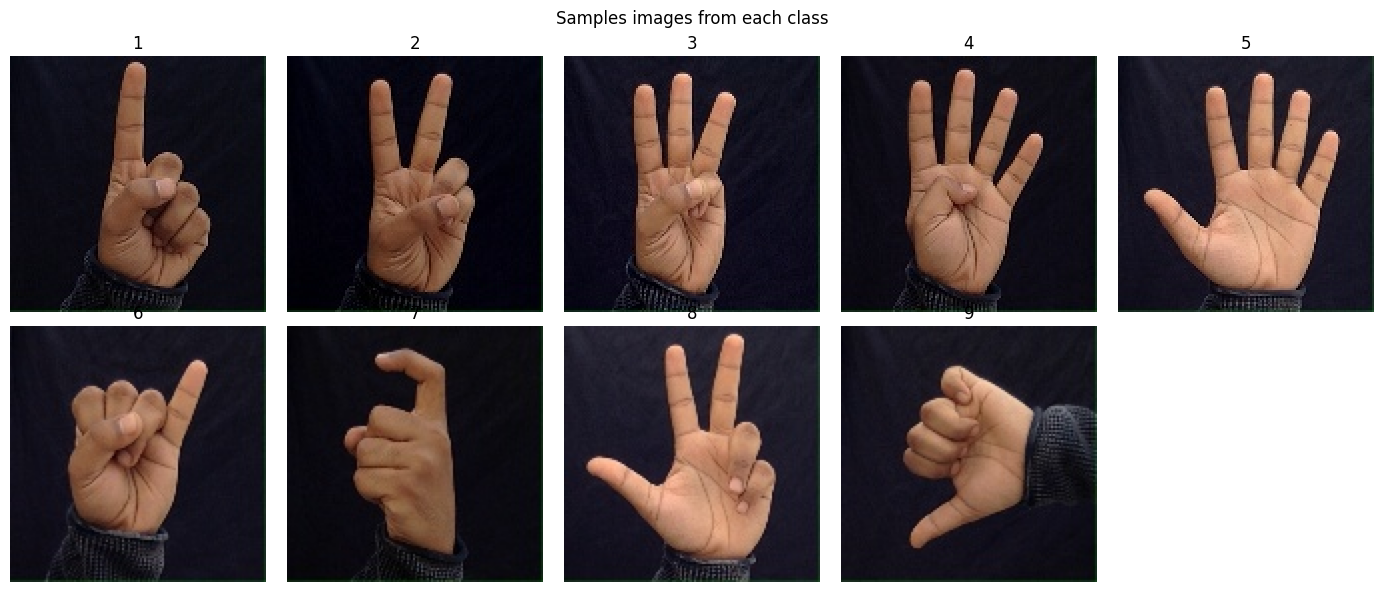

In [57]:
fig,axes = plt.subplots(2,5,figsize=(14,6))
axes = axes.flatten()

for i,cls in enumerate(CLASSES):
  axes[i].imshow(sample_imgs[cls])
  axes[i].set_title(cls)
  axes[i].axis('off')

axes[9].axis('off')

plt.suptitle('Samples images from each class')

plt.tight_layout()
plt.show()

In [58]:
#Question 2 from section 2

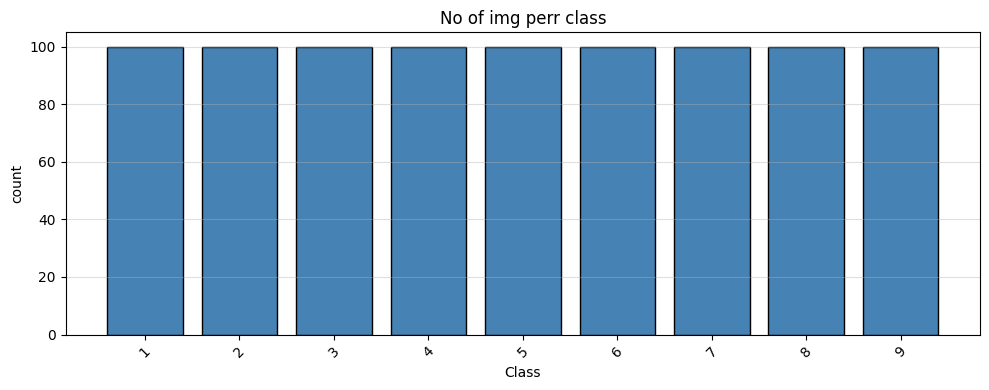

Mean 100.0
Median 100.0
Min 100 Max 100
Std: 0.0


In [59]:
counts = [train_counts[c] for c in CLASSES]

plt.figure(figsize = (10,4))
plt.bar(CLASSES,counts,color='steelblue',edgecolor ='black')
plt.title('No of img perr class')
plt.xlabel('Class')
plt.ylabel('count')
plt.xticks(rotation = 45)
plt.grid(axis='y',alpha=0.4)
plt.tight_layout()
plt.show()

print("Mean",round(np.mean(counts),1))
print("Median",round(np.median(counts),1))
print("Min",min(counts),"Max",max(counts))
print("Std:", round(np.std(counts), 1))

In [60]:
#Question 3 from Section 2

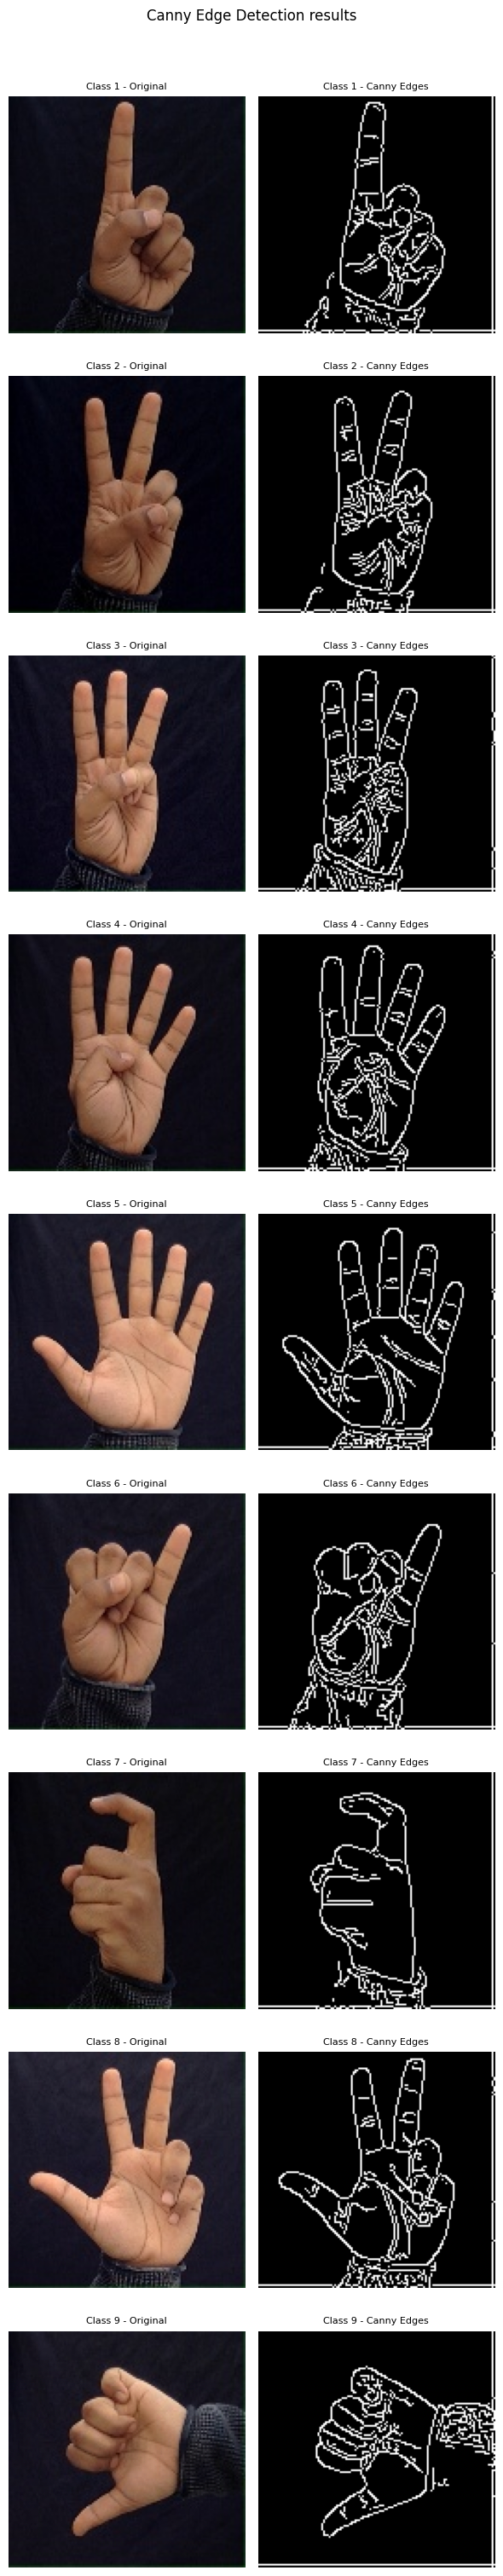

Canny Thresholds: lower = 50,upper = 150


In [61]:
fig,axes = plt.subplots(9,2,figsize = (6,30))
for i , cls in enumerate(CLASSES):
  img = sample_imgs[cls]
  gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
  edges = cv2.Canny(img,50,150)

  axes[i, 0].imshow(img)
  axes[i, 0].set_title('Class ' + cls + ' - Original', fontsize=8)
  axes[i, 0].axis('off')

  axes[i, 1].imshow(edges, cmap='gray')
  axes[i, 1].set_title('Class ' + cls + ' - Canny Edges', fontsize=8)
  axes[i, 1].axis('off')

plt.suptitle('Canny Edge Detection results',fontsize=12,y=1.01)
plt.tight_layout()
plt.show()

print("Canny Thresholds: lower = 50,upper = 150")


In [62]:
# cols = min(5,N_CLASSES)
# rows = (N_CLASSES + cols -1)//cols
# fig , axes = plt.subplots(rows*2,cols,figsize = (cols*2,rows*2))
# axes = axes.reshape(rows*2,cols)

# for idx , cls in enumerate(CLASSES):
#   r = idx//cols
#   c = idx%cols
#   if cls in sample_imgs:
#     img = cv2.resize(sample_imgs[cls],(128,128))
#     gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
#     edges = cv2.Canny(img,50,150)

#     axes[r*2,c].imshow(img)
#     axes[r*2,c].set_title(f'Original {cls}')
#     axes[r*2,c].axis('off')

#     axes[r*2+1,c].imshow(edges,cmap='gray')
#     axes[r*2+1,c].set_title(f'Edges {cls}')
#     axes[r*2+1,c].axis('off')

# for c in range(N_CLASSES%cols if N_CLASSES%cols != 0 else cols,cols):
#   axes[(rows-1*2),c].axis('off')
#   axes[(rows-1*2+1),c].axis('off')

# plt.suptitle('Canny Edge Detection')
# plt.tight_layout()
# plt.show()

In [63]:
#Question 4 from Section 2

In [64]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(tf.__version__)

2.19.0


In [65]:
BATCH_SIZE = 32
train_datagen= ImageDataGenerator(
    rescale = 1./225,
    rotation_range=10,
    horizontal_flip = True
)
test_datagen = ImageDataGenerator(rescale = 1./225)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

N_CLASSES = train_gen.num_classes
print(N_CLASSES)
print(train_gen.class_indices)
print(len(train_gen.classes))
print(len(test_gen.classes))


Found 900 images belonging to 9 classes.
Found 450 images belonging to 9 classes.
9
{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8}
900
450


In [66]:
# CNN architecture as given in the question
def build_cnn(n_classes):
    model = keras.Sequential()
    model.add(keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

    # block 1
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), padding='valid'))

    # block 2
    model.add(layers.Conv2D(32, (3,3), activation='relu', strides=2, padding='same'))
    model.add(layers.Conv2D(24, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), padding='valid'))

    # block 3
    model.add(layers.Conv2D(24, (3,3), activation='relu', strides=2, padding='same'))
    model.add(layers.Conv2D(16, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), padding='valid'))

    # classifier
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.05)))
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.05)))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(n_classes, activation='softmax'))

    return model

cnn_model = build_cnn(N_CLASSES)
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 24)     │         6,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 24)       │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,145 (215.41 KB)

 Trainable params: 55,001 (214.85 KB)

 Non-trainable params: 144 (576.00 B)

In [67]:
import tensorflow as tf

def my_cross_entropy(y_true,y_pred):
  y_pred = tf.clip_by_value(y_pred,1e-9,1.0)
  return -tf.reduce_mean(tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1))

a = tf.constant([[1.0,0.0,0.0], [0.0,1.0, 0.0]])
b = tf.constant([[0.8,0.1,0.1], [0.2,0.7,0.1]])\

print("My loss:", round(float(my_cross_entropy(a, b)), 5))
print("Keras loss:", round(float(keras.losses.categorical_crossentropy(a, b).numpy().mean()), 5))


My loss: 0.28991
Keras loss: 0.28991


In [68]:
from tensorflow.keras.callbacks import EarlyStopping

optimizers_list ={
    'SGD': keras.optimizers.SGD(learning_rate=0.01,momentum =0.9),
    'RMSprop': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
    'Adagrad': keras.optimizers.Adagrad(learning_rate=0.01)
}
early_stop = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.01,
    patience =2,
    restore_best_weights=True
)

histories={}
for name,opt in optimizers_list.items():
  print("Training with ",name)
  model = build_cnn(N_CLASSES)
  model.compile(
      optimizer = opt,
      loss = 'categorical_crossentropy',
      metrics = ['accuracy']
  )
  h= model.fit(train_gen,validation_data=test_gen,epochs=15,callbacks=[early_stop],verbose=1)
  histories[name] = h.history
  best_acc=max(h.history.get('val_accuracy',[0]))
  print(name,f"Best val accuracy: {round(best_acc*100,2)}%")
  print()

Training with  SGD
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.2456 - loss: 8.6775 - val_accuracy: 0.1111 - val_loss: 7.3167
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5256 - loss: 5.3898 - val_accuracy: 0.1111 - val_loss: 5.0826
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7311 - loss: 3.2227 - val_accuracy: 0.1111 - val_loss: 3.9586
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8611 - loss: 2.0641 - val_accuracy: 0.1111 - val_loss: 3.4840
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9056 - loss: 1.4414 - val_accuracy: 0.3333 - val_loss: 2.9831
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9400 - loss: 1.0828 - val_accuracy: 0.3511 - val_loss: 2.7611
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9422 - loss: 0.9092 - val_accuracy: 0.3356 - val_loss: 2.2778
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9878 - loss: 0.6866 - val_accuracy:

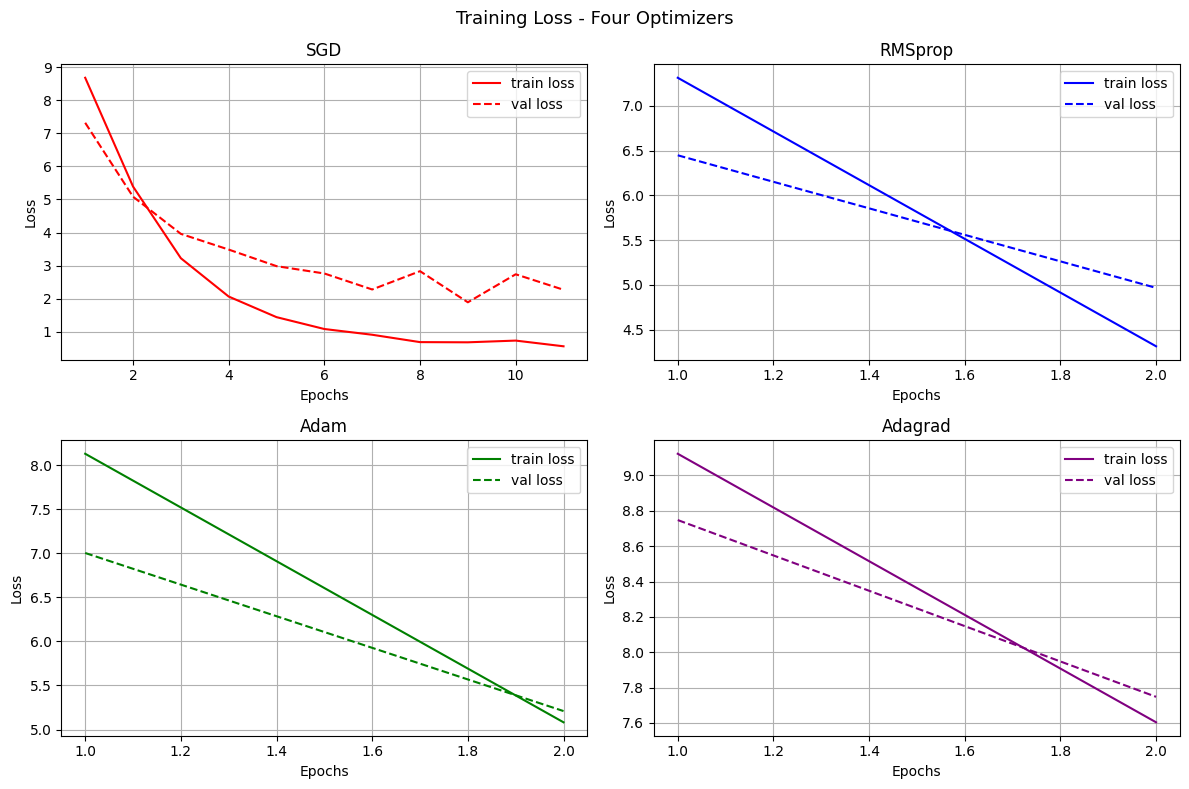

In [69]:
fig,axes = plt.subplots(2,2,figsize=(12,8))
axes = axes.flatten()
colors = ['red','blue','green','purple']

for i,name in enumerate(histories.keys()):
  hist = histories[name]
  ep = range(1,len(hist['loss'])+1)
  axes[i].plot(ep,hist['loss'],label='train loss',color=colors[i])
  axes[i].plot(ep,hist['val_loss'],label='val loss',color=colors[i],linestyle='--')
  axes[i].set_title(name)
  axes[i].set_xlabel("Epochs")
  axes[i].set_ylabel("Loss")
  axes[i].legend()
  axes[i].grid(True)

plt.suptitle('Training Loss - Four Optimizers', fontsize=13)
plt.tight_layout()
plt.show()

In [70]:
print()
print("Summary:")
print(f"{'Optimizer':<12} {'Best Val Acc':>13} {'Epochs Run':>11}")
print('-' * 38)
for name, hist in histories.items():
    best = max(hist.get('val_accuracy', [0])) * 100
    ep   = len(hist['loss'])
    print(f"{name:<12} {best:>12.2f}%  {ep:>10}")


Summary:
Optimizer     Best Val Acc  Epochs Run
--------------------------------------
SGD                 45.78%          11
RMSprop             14.89%           2
Adam                23.56%           2
Adagrad             11.11%           2


In [71]:
#Question 5 from section 2

In [72]:
def build_cnn_v2(n_classes,dropout_rate = 0.4):
  model =keras.Sequential()
  model.add(keras.Input(shape=(IMG_SIZE,IMG_SIZE,3)))
  model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.MaxPooling2D((2,2)))

  model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.MaxPooling2D((2,2)))

  model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
  model.add(layers.GlobalAveragePooling2D())

  model.add(layers.Dense(128, activation='relu'))
  model.add(layers.Dropout(dropout_rate))
  model.add(layers.Dense(n_classes, activation='softmax'))

  return model

configs = {
    'Original' : build_cnn(N_CLASSES),
    'Deeper, dropout=0.4': build_cnn_v2(N_CLASSES, 0.4),
    'Deeper, dropout=0.2': build_cnn_v2(N_CLASSES, 0.2)
}

hist_exp = {}
for name, m in configs.items():
    print("Training:", name)
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_gen, validation_data=test_gen,
              epochs=10, callbacks=[early_stop], verbose=0)
    hist_exp[name] = h.history
    best = max(h.history.get('val_accuracy', [0])) * 100
    print("best val acc:", round(best, 2), "%")

Training: Original
best val acc: 11.11 %
Training: Deeper, dropout=0.4
best val acc: 22.22 %
Training: Deeper, dropout=0.2
best val acc: 22.22 %


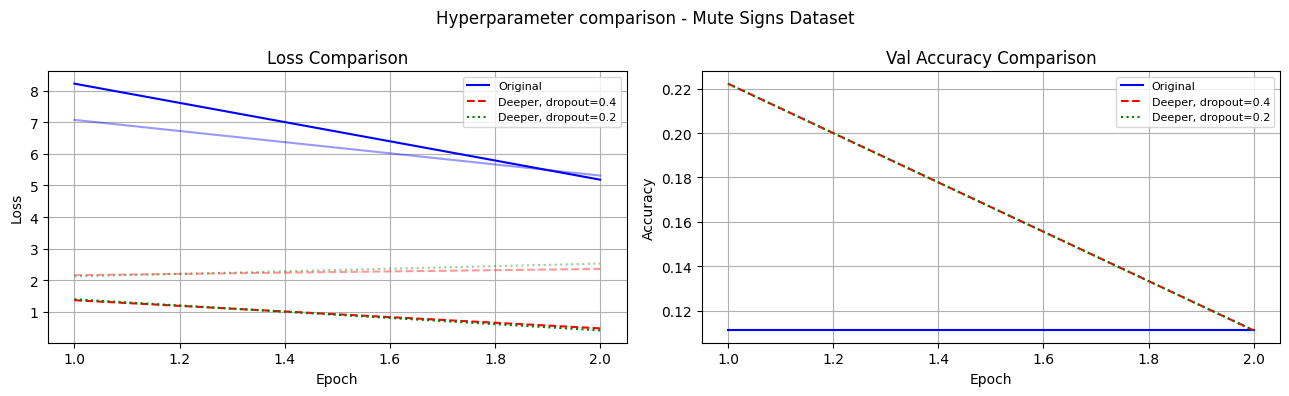

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
styles = ['-', '--', ':']
exp_colors = ['blue', 'red', 'green']

for (name, hist), ls, col in zip(hist_exp.items(), styles, exp_colors):
    ep = range(1, len(hist['loss'])+1)
    axes[0].plot(ep, hist['loss'],    label=name, linestyle=ls, color=col)
    axes[0].plot(ep, hist['val_loss'],linestyle=ls, color=col, alpha=0.4)
    axes[1].plot(ep, hist.get('val_accuracy', [0]*len(ep)), label=name, linestyle=ls, color=col)

axes[0].set_title('Loss Comparison'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].set_title('Val Accuracy Comparison'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8); axes[1].grid(True)

plt.suptitle("Hyperparameter comparison - Mute Signs Dataset")
plt.tight_layout()
plt.show()


---

Section 3:  (Total points = 55)

---

Q3. In this question, we will implement a character-level Recurrent Neural Network (RNN) from scratch to perform next character prediction using the Tiny Shakespeare dataset.

Dataset is provided below:

https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt  

- Treat the dataset as a continuous stream of characters  
- Do not remove special characters (including newline)  
- Use overlapping sliding window sequences  

---

1. Explore the dataset. Print total number of characters and display a sample text snippet from the dataset. Also list all unique characters and compute vocabulary size. (2 points)

---

2. Perform data preprocessing on the dataset. Convert all text to lowercase and create character-to-index and index-to-character mappings. Convert the dataset into integer indices.

Generate input-output sequences using an overlapping sliding window approach (sequence length = 25, stride = 1), where the target sequence is shifted by one character.

Convert each character in input sequences into one-hot encoded vectors of size (vocab_size, 1).

Display one example:
- Input sequence (characters)  
- Target sequence (characters)  
- Corresponding indices  

(5 points)

---

3. Implement a vanilla Recurrent Neural Network (RNN) from scratch (do not use deep learning libraries). Define and initialize the parameters:

Wxh, Whh, Why, bh, by

The forward pass should follow:

ht = tanh(Wxh xt + Whh h(t-1) + bh)  
yt = Why ht + by  
pt = softmax(yt)  

Initialize the hidden state as zeros and process the sequence step-by-step.

Clearly define input size, hidden size and output size. Display the dimensions of all parameters and show output probabilities for one time step. (10 points)

---

4. Implement Backpropagation Through Time (BPTT) to train the RNN. Compute gradients of all parameters using chain rule across time steps.

- Backpropagate through all time steps in reverse order  
- Use derivative of tanh: (1 - h^2)  
- Accumulate gradients across the sequence  

Implement gradient clipping in the range [-5, 5] to handle exploding gradients.

(15 points)

---

5. Train your model using cross-entropy loss (error function). Implement cross-entropy loss manually (do not use built-in functions).

- Print training loss at regular intervals (e.g., every 500 iterations)  
- Plot training loss versus iterations  
- Reset hidden state when reaching end of dataset  

Generate sample text from the trained model using a seed character and display the generated output (minimum 100 characters).

(10 points)

---

6. Train your RNN with different hidden layer sizes given as [32, 64, 128]. Use the same hyperparameters for fair comparison.

- Record final training loss  
- Generate sample text for each model  

Present your results in a table and comment on the differences in performance and text quality. (5 points)

---

7. Perform analysis on the trained model:

(a) Generate sequences using different seed inputs such as "the", "king", "love" and compare outputs.  

(b) Implement temperature-based sampling:

p_i = exp(y_i / T) / sum(exp(y_j / T))

Test for T = [0.5, 1.0, 1.5] and compare diversity and coherence of generated text.  

(c) Train the model with different sequence lengths [10, 25, 50] and compare training loss and generated outputs.  

(d) Perform error analysis by identifying cases of:
- Repetition  
- Meaningless outputs  
- Broken sentences  

Explain possible reasons such as vanishing gradients, limited context or insufficient training.  

(8 points)

---

In [74]:
import numpy as np
import requests
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text
print("First 500 Char")
print(text[:500])

unique_chars = sorted(set(text))
vocab_size = len(unique_chars)
print("Vocab size:", vocab_size)
print("Unique chars:", unique_chars)
print(repr(''.join(unique_chars)))

First 500 Char
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
Vocab size: 65
Unique chars: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


In [75]:
#convert to lowercase
text = text.lower()
unique_chars = sorted(set(text))
vocab_size = len(unique_chars)
print("Vocab size:", vocab_size)
print("Unique chars:", unique_chars)

char_to_idx = {ch: i for i, ch in enumerate(unique_chars)}
idx_to_char = {i: ch for i, ch in enumerate(unique_chars)}

data = []
for ch in text:
    data.append(char_to_idx[ch])
data = np.array(data)
print(data.shape)

Vocab size: 39
Unique chars: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
(1115394,)


In [76]:
# one-hot encoding function
def one_hot(idx, size):
    v = np.zeros((size, 1))
    v[idx, 0] = 1.0
    return v

SEQ_LEN = 25

# show one example
inp_idx = data[0:SEQ_LEN]
tgt_idx = data[1:SEQ_LEN+1]

inp_chars = ''.join([idx_to_char[i] for i in inp_idx])
tgt_chars = ''.join([idx_to_char[i] for i in tgt_idx])

print("Input chars:", repr(inp_chars))
print("Target chars:", repr(tgt_chars))
print("Input indices:", list(inp_idx))
print("Target indices:", list(tgt_idx))
print()
print("One-hot for first char '{}':".format(inp_chars[0]))
print("Shape:", one_hot(inp_idx[0], vocab_size).shape)
print("Value at index", inp_idx[0], ":", one_hot(inp_idx[0], vocab_size)[inp_idx[0], 0])


Input chars: 'first citizen:\nbefore we '
Target chars: 'irst citizen:\nbefore we p'
Input indices: [np.int64(18), np.int64(21), np.int64(30), np.int64(31), np.int64(32), np.int64(1), np.int64(15), np.int64(21), np.int64(32), np.int64(21), np.int64(38), np.int64(17), np.int64(26), np.int64(10), np.int64(0), np.int64(14), np.int64(17), np.int64(18), np.int64(27), np.int64(30), np.int64(17), np.int64(1), np.int64(35), np.int64(17), np.int64(1)]
Target indices: [np.int64(21), np.int64(30), np.int64(31), np.int64(32), np.int64(1), np.int64(15), np.int64(21), np.int64(32), np.int64(21), np.int64(38), np.int64(17), np.int64(26), np.int64(10), np.int64(0), np.int64(14), np.int64(17), np.int64(18), np.int64(27), np.int64(30), np.int64(17), np.int64(1), np.int64(35), np.int64(17), np.int64(1), np.int64(28)]

One-hot for first char 'f':
Shape: (39, 1)
Value at index 18 : 1.0


In [77]:
class CharRNN:

    def __init__(self, vocab_size, hidden_size):
        self.vocab_size  = vocab_size
        self.hidden_size = hidden_size

        np.random.seed(42)

        # weights - small random values work well to start
        self.Wxh = np.random.randn(hidden_size, vocab_size)  * 0.01  # input -> hidden
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01  # hidden -> hidden
        self.Why = np.random.randn(vocab_size,  hidden_size) * 0.01  # hidden -> output
        self.bh  = np.zeros((hidden_size, 1))
        self.by  = np.zeros((vocab_size, 1))

    def softmax(self, z):
        z = z - np.max(z)   # subtract max to avoid overflow
        e = np.exp(z)
        return e / np.sum(e)

    def forward(self, inputs, h_prev):
        # inputs: list of one-hot vectors
        xs = {}   # store inputs at each step
        hs = {}   # store hidden states
        ys = {}   # store raw outputs
        ps = {}   # store probabilities

        hs[-1] = h_prev.copy()

        for t in range(len(inputs)):
            xs[t] = inputs[t]
            hs[t] = np.tanh(np.dot(self.Wxh, xs[t]) + np.dot(self.Whh, hs[t-1]) + self.bh)
            ys[t] = np.dot(self.Why, hs[t]) + self.by
            ps[t] = self.softmax(ys[t])

        return xs, hs, ys, ps

    def loss(self, ps, targets):
        total = 0.0
        for t in range(len(targets)):
            total -= np.log(ps[t][targets[t], 0] + 1e-9)
        return total

    def bptt(self, xs, hs, ps, targets):
        # initialize gradient arrays as zeros
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh  = np.zeros_like(self.bh)
        dby  = np.zeros_like(self.by)
        dh_next = np.zeros((self.hidden_size, 1))

        for t in reversed(range(len(targets))):
            # gradient of loss w.r.t output (softmax + cross entropy derivative)
            dy = ps[t].copy()
            dy[targets[t]] -= 1

            dWhy += np.dot(dy, hs[t].T)
            dby  += dy

            # backprop into hidden state
            dh = np.dot(self.Why.T, dy) + dh_next

            # tanh derivative: 1 - h^2
            dh_tanh = (1 - hs[t] * hs[t]) * dh

            dbh  += dh_tanh
            dWxh += np.dot(dh_tanh, xs[t].T)
            dWhh += np.dot(dh_tanh, hs[t-1].T)
            dh_next = np.dot(self.Whh.T, dh_tanh)

        # clip gradients to avoid exploding gradient problem
        for grad in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(grad, -5, 5, out=grad)

        return dWxh, dWhh, dWhy, dbh, dby

    def update(self, grads, lr=0.1):
        # simple gradient descent update
        dWxh, dWhh, dWhy, dbh, dby = grads
        self.Wxh -= lr * dWxh
        self.Whh -= lr * dWhh
        self.Why -= lr * dWhy
        self.bh  -= lr * dbh
        self.by  -= lr * dby

    def generate(self, seed_idx, length=100, temp=1.0, h=None):
        if h is None:
            h = np.zeros((self.hidden_size, 1))
        x = one_hot(seed_idx, self.vocab_size)
        result = []
        for _ in range(length):
            h = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h) + self.bh)
            y = np.dot(self.Why, h) + self.by
            y = y / temp
            y = y - np.max(y)
            p = np.exp(y) / np.sum(np.exp(y))
            next_char = np.random.choice(self.vocab_size, p=p.ravel())
            result.append(next_char)
            x = one_hot(next_char, self.vocab_size)
        return ''.join([idx_to_char[i] for i in result])


# check dimensions
rnn = CharRNN(vocab_size, hidden_size=64)
print("Wxh shape:", rnn.Wxh.shape)
print("Whh shape:", rnn.Whh.shape)
print("Why shape:", rnn.Why.shape)
print("bh shape:", rnn.bh.shape)
print("by shape:", rnn.by.shape)

h0 = np.zeros((64, 1))
test_in = [one_hot(data[i], vocab_size) for i in range(SEQ_LEN)]
xs_t, hs_t, ys_t, ps_t = rnn.forward(test_in, h0)

print()
print("h_t shape:", hs_t[0].shape)
print("p_t shape:", ps_t[0].shape)
print("p_t sums to:", round(float(ps_t[0].sum()), 5))


Wxh shape: (64, 39)
Whh shape: (64, 64)
Why shape: (39, 64)
bh shape: (64, 1)
by shape: (39, 1)

h_t shape: (64, 1)
p_t shape: (39, 1)
p_t sums to: 1.0


In [78]:
#question 4 from section 3

In [79]:
rnn_check = CharRNN(vocab_size,64)
h0 = np.zeros((64, 1))
inp_seq = [one_hot(data[i], vocab_size) for i in range(SEQ_LEN)]
tgt_seq = [int(data[i+1]) for i in range(SEQ_LEN)]

xs_c , hs_c , ys_c , ps_c = rnn_check.forward(inp_seq,h0)
loss_val = rnn_check.loss(ps_c,tgt_seq)
print("Loss:", loss_val)
grads_c = rnn_check.bptt(xs_c,hs_c,ps_c,tgt_seq)

print()
print("Gradient stats after clipping to [-5, 5]:")
names = ['dWxh', 'dWhh', 'dWhy', 'dbh', 'dby']
for name, g in zip(names, grads_c):
    print(f"  {name}: min={round(g.min(),3)}  max={round(g.max(),3)}  norm={round(float(np.linalg.norm(g)),3)}")


Loss: 91.58781389328988

Gradient stats after clipping to [-5, 5]:
  dWxh: min=-0.049  max=0.051  norm=0.417
  dWhh: min=-0.002  max=0.002  norm=0.031
  dWhy: min=-0.05  max=0.048  norm=0.396
  dbh: min=-0.169  max=0.135  norm=0.537
  dby: min=-3.359  max=0.641  norm=6.081


In [80]:
#question 5 from section 3

In [81]:
HIDDEN = 64
LR = 0.1
N_ITER = 3000
PRINT_AT = 500

rnn = CharRNN(vocab_size,HIDDEN)

smooth_loss = -np.log(1.0/vocab_size)*SEQ_LEN
ptr = 0
h_prev = np.zeros((HIDDEN,1))
loss_history=[]

for it in range(N_ITER):
  if ptr+SEQ_LEN +1 >= len(data):
    ptr =0
    h_prev = np.zeros((HIDDEN,1))
  inputs = [one_hot(data[ptr+t],vocab_size) for t in range(SEQ_LEN)]
  targets=[int(data[ptr+t+1]) for t in range(SEQ_LEN)]
  ptr += SEQ_LEN

  xs , hs , ys , ps = rnn.forward(inputs,h_prev)
  seq_loss = rnn.loss(ps,targets)
  grads = rnn.bptt(xs,hs,ps,targets)
  rnn.update(grads,lr=LR)

  smooth_loss = 0.999*smooth_loss+0.001*seq_loss
  loss_history.append(smooth_loss)

  h_prev = hs[SEQ_LEN-1]

  if it%PRINT_AT ==0:
    print(f"iter {it} loss: {round(smooth_loss,3)}")
    sample = rnn.generate(char_to_idx['t'], length=80)
    print("sample:", repr(sample))
    print()

  print("Done with trainign")


iter 0 loss: 91.589
sample: " c:z?vnaitv,aa kucplc'oun\n.!jq&tioy$w&cuwgkot&sfedgxiy-psnkius&td:ues:\ng$q:e$;r'"

Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with trainign
Done with tr

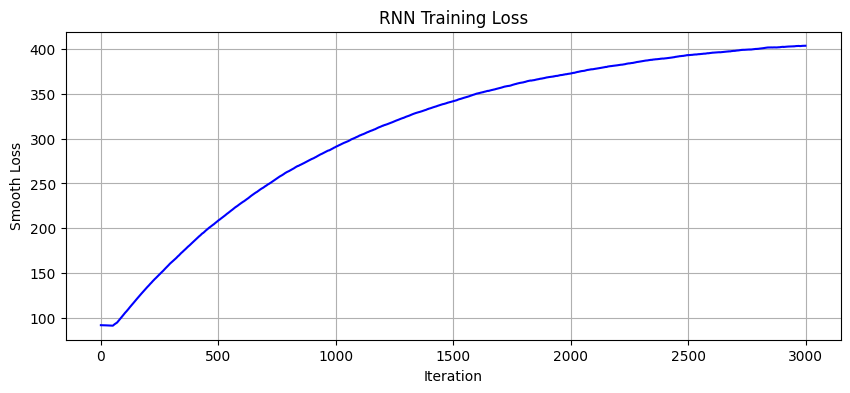

Generated text (150 chars):
  hhh hhhhhhhhhhh h hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh hhh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh


In [82]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Smooth Loss')
plt.grid(True)
plt.show()

print("Generated text (150 chars):")
print(rnn.generate(char_to_idx['t'], length=150))


In [83]:
#Question 6 from section 3

In [84]:
hidden_sizes = [32, 64, 128]
N_ITER_EXP = 2000

results = {}

for h_size in hidden_sizes:
    print("Training with hidden size =", h_size)

    model = CharRNN(vocab_size, h_size)
    s_loss = -np.log(1.0/vocab_size)* SEQ_LEN
    ptr = 0
    h_state = np.zeros((h_size,1))
    losses = []

    for it in range(N_ITER_EXP):
        if ptr + SEQ_LEN + 1 >=len(data):
            ptr = 0
            h_state = np.zeros((h_size,1))

        inputs  = [one_hot(data[ptr+t], vocab_size) for t in range(SEQ_LEN)]
        targets= [int(data[ptr+t+1]) for t in range(SEQ_LEN)]
        ptr +=SEQ_LEN

        xs,hs,ys,ps = model.forward(inputs, h_state)
        seq_loss= model.loss(ps, targets)
        s_loss= 0.999 * s_loss + 0.001 * seq_loss

        grads =model.bptt(xs, hs, ps, targets)
        model.update(grads,lr=0.1)

        h_state = hs[SEQ_LEN -1]
        losses.append(s_loss)

    sample = model.generate(char_to_idx['t'],80)
    results[h_size] = {'final_loss': s_loss,'losses':losses, 'sample': sample}
    print(f"final loss: {round(s_loss, 4)}")
    print(f"sample: {repr(sample)}")
    print()


Training with hidden size = 32
final loss: 201.6416
sample: 'niuene\n\nuftt\n\nmeee mhene\noaese\nomese \nhene\n\nmas  rhe.e \nmfa  muese rmaee\n\nmeee\n\n'

Training with hidden size = 64
final loss: 372.8201
sample: 'ahhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh'

Training with hidden size = 128
final loss: 399.7035
sample: 'eo oooo  tt  t     e tttto    et eo te to eo tteot to oe oeo eottt t   t   et e '



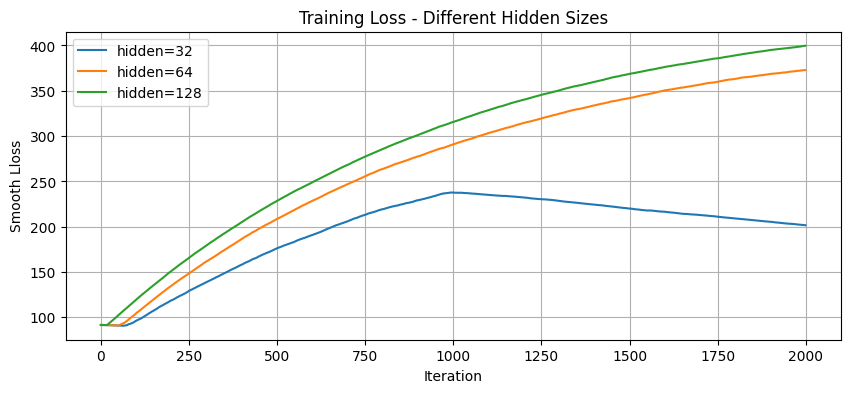

Summary:
    Hidden   Final Loss       Params
------------------------------------
        32     201.6416        3,591
        64     372.8201        9,191
       128     399.7035       26,535


In [85]:
plt.figure(figsize=(10, 4))
for h_size in hidden_sizes:
    plt.plot(results[h_size]['losses'],label='hidden='+str(h_size))
plt.title('Training Loss - Different Hidden Sizes')
plt.xlabel('Iteration')
plt.ylabel('Smooth Lloss')
plt.legend()
plt.grid(True)
plt.show()

print("Summary:")
print(f"{'Hidden':>10} {'Final Loss':>12} {'Params':>12}")
print('-' * 36)
for h in hidden_sizes:
    params = vocab_size*h + h*h + h*vocab_size + h + vocab_size
    print(f"{h:>10} {results[h]['final_loss']:>12.4f} {params:>12,}")

In [86]:
#Question 7 from section 3

In [87]:
print("Part A")
for seed_char , word in [('t','the'),('k','king'),('l','love')]:
  if seed_char in char_to_idx:
    gen = rnn.generate(char_to_idx[seed_char],length=120)
    print(f"Seed '{word} ( starts with '{seed_char}'):")
    print(gen)
    print()

Part A
Seed 'the ( starts with 't'):
  hhhhhh hhhhhh  hhhhhhh hhhhhhhh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhh hhh hhhhhhhhhhhhhh

Seed 'king ( starts with 'k'):
 hhhhhhh hhhhhhhhhhhhhhhhhhhhhhhhhhh hhh  hh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh hhhhhhhhhhhhhhhhhhhhhh hhhh

Seed 'love ( starts with 'l'):
 hhhhhhhhhhhhhhhhhhh hh hhhhhhh  hhhhhhhhhhhhhhhhhhhhhhhhh hhhhhhhhhhhhhhhhhhh hhhhhhhhh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh



In [88]:
print("part B")
for T in [0.5,1.0,1.5]:
  gen = rnn.generate(char_to_idx['t'],length=120,temp=T)
  print(f"T={T}:")
  print(gen)
  print()

part B
T=0.5:
  hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

T=1.0:
  hhhhhhhhhhhhhhhhhhh hhhhh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh hhhhhhhhhhhhhhhhhhh hhhhh hhhhhhhh hhhhhhhhhhhhhhhhh

T=1.5:
   hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh hhhhhhhh hhhhhhhhhhhhhhhhhh hhhhh hhhhhh hhhhhhhhhhhh hhhhh hhhhh hhhhhhh h hhhhh



part C
seq_len=10: final loss=117.1179
sample: ' ttthtttttthtthtttttthttthhhtthtttththttttttthtttttttthttttttthtthttthhthththhth'

seq_len=25: final loss=341.8395
sample: '                                                                                '

seq_len=50: final loss=634.1877
sample: ' a  mts tt et\n et\n et\n et\n ett ets et\n ets et\n et\n ntw ets ett et\n et\n ett et\n e'



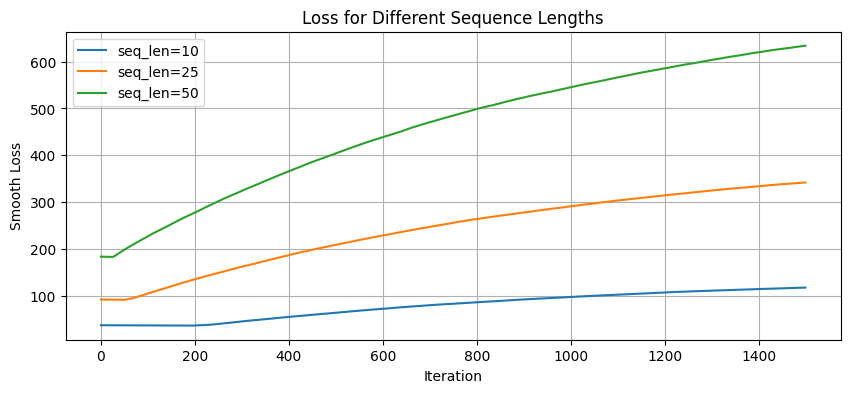

In [89]:
print("part C")


seq_results = {}

for seq_len in [10, 25, 50]:
    model_sl = CharRNN(vocab_size, 64)
    s_loss = -np.log(1.0 / vocab_size) * seq_len
    ptr = 0
    h_sl = np.zeros((64, 1))
    losses_sl = []

    for it in range(1500):
        if ptr + seq_len + 1 >= len(data):
            ptr = 0
            h_sl = np.zeros((64, 1))
        inputs  = [one_hot(data[ptr+t], vocab_size) for t in range(seq_len)]
        targets = [int(data[ptr+t+1])               for t in range(seq_len)]
        ptr += seq_len
        xs, hs, ys, ps = model_sl.forward(inputs, h_sl)
        seq_loss = model_sl.loss(ps, targets)
        s_loss = 0.999 * s_loss + 0.001 * seq_loss
        grads = model_sl.bptt(xs, hs, ps, targets)
        model_sl.update(grads, lr=0.1)
        h_sl = hs[seq_len - 1]
        losses_sl.append(s_loss)

    sample_sl = model_sl.generate(char_to_idx['t'], 80)
    seq_results[seq_len] = {'final_loss': s_loss, 'losses': losses_sl}
    print(f"seq_len={seq_len}: final loss={round(s_loss, 4)}")
    print("sample:", repr(sample_sl))
    print()

plt.figure(figsize=(10, 4))
for seq_len in [10, 25, 50]:
    plt.plot(seq_results[seq_len]['losses'], label='seq_len='+str(seq_len))
plt.title('Loss for Different Sequence Lengths')
plt.xlabel('Iteration')
plt.ylabel('Smooth Loss')
plt.legend()
plt.grid(True)
plt.show()


In [90]:
print("Part D")
gen_text = rnn.generate(char_to_idx['t'],length = 300)
print(gen_text)
print()

words = gen_text.split()
print("total words:",len(words))
print("Unique Words:",len(set(words)))
rep = sum(1 for i in range(len(words)-1) if words[i]==words[i+1])
print("Consecutive Words repeated ",rep)

Part D
  hhhhhhhhh hhhhhhhhhhhhhhhhhhhh hhhhh hh hhhhh hhhhhhhhhhhhhhhhhhhhhhhh hhhhhhhhhhhhhhhhhhhh hhhh hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh  hhhhhhhhhhhhhhhhhhh    hhhhhhhhhhhhhhhhhhhh hhhhhhhhhhhhhhh  hhhhhhhhhhhhhhhhhhhh hhhhhhhhhh hhhhhhhhhhhhhhhhhhhh hhhhh hhhhhhhh

total words: 17
Unique Words: 11
Consecutive Words repeated  0
